# Do Words Move Markets?
## NLP Analysis of Public Figure Tweets & S&P 500 Reactions

**Team Eclipse, DSO 560, USC Marshall, Spring 2026**

> This is my (Olivia Cai's) cleaned portfolio version of an 8-person team project. Full attribution available on request.

---

### Notebook Structure
| Section | Content |
|---------|--------|
| 1 | Environment Setup & Global Imports |
| 2 | Data Loading & Cleaning (Task 1) |
| 3 | EDA: Summary Statistics (Task 1) |
| 4 | Word Frequency Analysis (Task 2) |
| 5 | Named Entity Recognition & POS Tagging (Task 3) |
| 6 | Sentiment Analysis, VADER (Task 4) |
| 7 | Topic Modeling, LDA (Task 5) |
| 8 | Predictive Modeling (Task 6) |

---

**Data source:** the merged input file lives at `./data/cleaned/merged_cleaned_df.csv` by default. The location can be overridden by setting the `ECLIPSE_DATA_DIR` environment variable. The file joins all text sources (Trump tweets, Musk tweets, presidential speeches) with S&P 500 daily returns on `date`.

> **How to run:** the notebook runs locally (Jupyter or VS Code) or in Google Colab. Execute cells top to bottom. All outputs are self-contained and figures are written to `./figures/`.

---
## Section 1. Environment Setup & Global Imports

In [1]:
import os

os.environ["ECLIPSE_DATA_DIR"] = "../data/cleaned"

In [2]:
%%capture
# Install all third-party packages needed across the entire notebook.
# Run this cell first; Colab will restart the kernel if prompted.
!pip install vaderSentiment gensim pyLDAvis textblob spacy scikit-learn -q
!python -m spacy download en_core_web_sm -q
import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    nltk.download(pkg, quiet=True)

In [3]:
# ── Core scientific and data libraries ──────────────────────────────────────
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm

# ── NLP libraries ─────────────────────────────────────────────────────────────
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.util import bigrams
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import spacy
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, Phrases
from gensim.models.phrases import Phraser
import pyLDAvis
import pyLDAvis.gensim_models
import wordcloud

# ── Machine learning libraries ───────────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from scipy.sparse import hstack, csr_matrix

# ── Global settings ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

In [4]:
import warnings
# Suppress noisy DeprecationWarnings from gensim, sklearn, and nltk so the notebook output stays readable.
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [5]:
import os

DATA_DIR = os.environ.get("ECLIPSE_DATA_DIR", "./data/cleaned")
os.makedirs("figures", exist_ok=True)

# Optional Colab support: if running in Colab, mount Google Drive on demand.
# Wrapped in try/except so the notebook also runs locally without Colab installed.
try:
    from google.colab import drive  # noqa: F401
    # Uncomment the next two lines if you want to load data from Google Drive in Colab:
    # drive.mount('/content/drive')
    # DATA_DIR = '/content/drive/MyDrive/NLP Group Project/Cleaned Datasets'
except ImportError:
    pass

print('Data directory:', DATA_DIR)

Data directory: ../data/cleaned


---
## Section 2. Data Loading & Cleaning (Task 1)

We merge four pre-cleaned CSV files (Trump tweets, Elon Musk tweets, presidential speeches, and S&P 500 daily returns) on `date` to create a single analysis-ready dataframe.

**Data sources:**
- Trump tweets (Kaggle): 42,849 records, 2010–2020
- Elon Musk tweets (Kaggle): 16,744 records, 2011–2023
- Presidential speeches (Kaggle): 995 records, 2010–2023
- S&P 500 daily returns (yfinance): 3,521 trading days, 2010–2023

**Key variables in merged dataset:** `date`, `text`, `by` (speaker), `Close` (closing price), `return` (daily return).

In [6]:
# Load each cleaned CSV and parse date columns.
speech = pd.read_csv(os.path.join(DATA_DIR, 'speech_clean.csv'))
trump  = pd.read_csv(os.path.join(DATA_DIR, 'trump_clean.csv'))
musk   = pd.read_csv(os.path.join(DATA_DIR, 'musk_clean.csv'))
stocks = pd.read_csv(os.path.join(DATA_DIR, 'stocks_clean.csv'))
text   = pd.read_csv(os.path.join(DATA_DIR, 'all_text_clean.csv'))  # combined text

for df_tmp in [speech, trump, musk, stocks, text]:
    df_tmp['date'] = pd.to_datetime(df_tmp['date'])

print(f'Speech: {len(speech):,} rows | Trump: {len(trump):,} | Musk: {len(musk):,}')
print(f'Stocks: {len(stocks):,} rows | All text combined: {len(text):,}')

Speech: 995 rows | Trump: 56,571 | Musk: 24,450
Stocks: 3,521 rows | All text combined: 82,016


In [7]:
# Inner-join text data with stock returns on date.
# 'Inner' means we only keep dates that appear in both datasets
# (i.e., trading days that also have at least one text record).
df = pd.read_csv(os.path.join(DATA_DIR, 'merged_cleaned_df.csv'))
df['date'] = pd.to_datetime(df['date'])

# Standardise speaker labels for consistency across the notebook.
df['by'] = df['by'].replace({'realDonaldTrump': 'Donald Trump', 'elonmusk': 'Elon Musk'})

print(f'Merged dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('\nSpeaker distribution:')
print(df['by'].value_counts())
print('\nDate range:', df['date'].min().date(), '→', df['date'].max().date())
print('\nMissing values:')
print(df.isnull().sum())

Merged dataset: 16,821 rows × 5 columns

Speaker distribution:
by
Elon Musk       16744
Donald Trump       43
Barack Obama       34
Name: count, dtype: int64

Date range: 2010-01-27 → 2023-06-29

Missing values:
date      0
text      0
by        0
Close     0
return    0
dtype: int64


---
## Section 3. EDA: Summary Statistics (Task 1)

Basic descriptive statistics to understand the distribution of text length, tweet volume over time, and S&P 500 return characteristics.

In [8]:
# ── Text length distribution ─────────────────────────────────────────────────
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(str(x).split()))

print('Text length statistics (characters):')
print(df['text_length'].describe().round(1))

print('\nS&P 500 daily return statistics:')
print(df['return'].describe().round(6))

Text length statistics (characters):
count    16821.0
mean       154.1
std       1405.8
min          1.0
25%         29.0
50%         57.0
75%        113.0
max      32759.0
Name: text_length, dtype: float64

S&P 500 daily return statistics:
count    16821.000000
mean         0.000627
std          0.012398
min         -0.109424
25%         -0.005124
50%          0.000580
75%          0.006878
max          0.090603
Name: return, dtype: float64


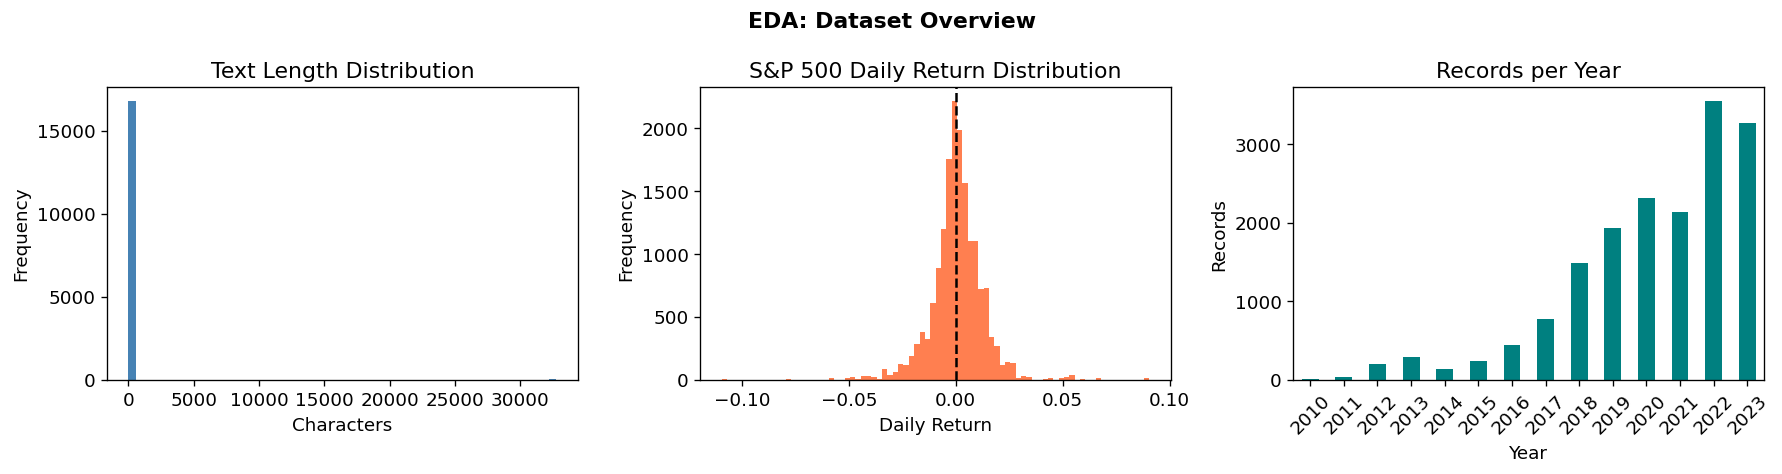

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Text length distribution
axes[0].hist(df['text_length'], bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Text Length Distribution')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')

# S&P 500 daily return distribution
axes[1].hist(df['return'], bins=80, color='coral', edgecolor='none')
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('S&P 500 Daily Return Distribution')
axes[1].set_xlabel('Daily Return')
axes[1].set_ylabel('Frequency')

# Records per year
df.groupby(df['date'].dt.year).size().plot(kind='bar', ax=axes[2], color='teal')
axes[2].set_title('Records per Year')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Records')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('EDA: Dataset Overview', fontweight='bold')
plt.tight_layout()
plt.show()

Speech length by president:
                       count     mean      std      min      25%      50%  \
user_name                                                                   
Abraham Lincoln         15.0  22051.0  13256.0    812.0  11402.0  32759.0   
Andrew Jackson          26.0  21322.0  13874.0   1791.0   5614.0  32759.0   
Andrew Johnson          31.0  15442.0  11608.0   1555.0   6010.0  10728.0   
Barack Obama            50.0  22285.0   8987.0   4938.0  13798.0  24225.0   
Benjamin Harrison       23.0  18549.0  14795.0   1162.0   2713.0  26014.0   
Bill Clinton            39.0  17884.0  11447.0   3046.0   7072.0  13253.0   
Calvin Coolidge         12.0  27359.0   8717.0   6265.0  25709.0  32759.0   
Chester A. Arthur       11.0  16954.0  13250.0   1927.0   5952.0  11106.0   
Donald Trump            22.0  21156.0  10788.0   3225.0  10386.0  23630.0   
Dwight D. Eisenhower     6.0  17702.0   5157.0  11213.0  14564.0  17177.0   
Franklin D. Roosevelt   49.0  15477.0   7023.0  

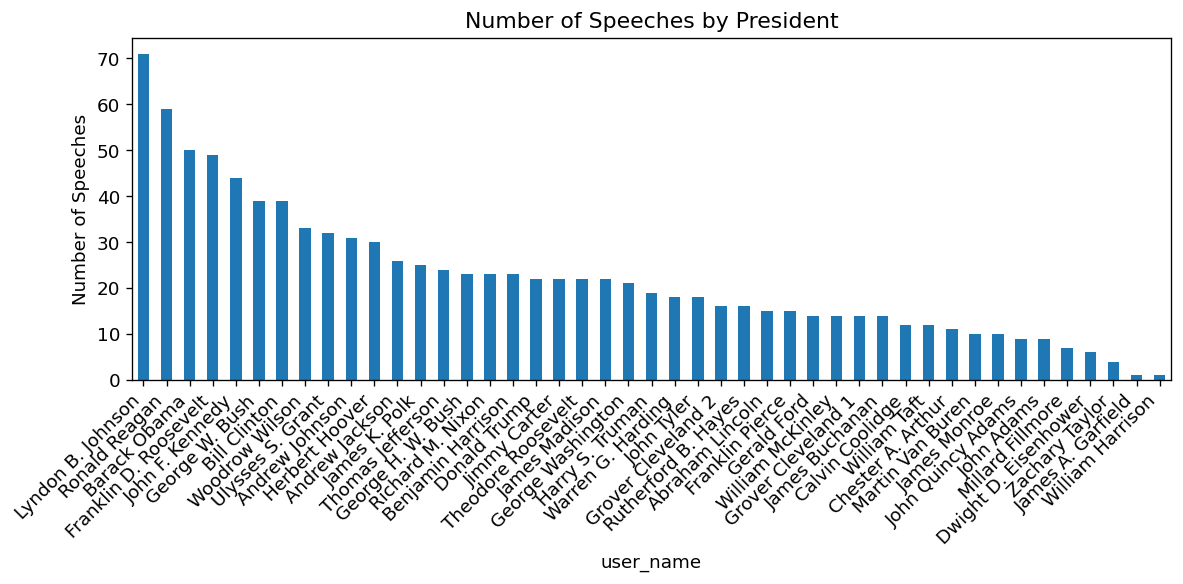

In [10]:
# Speech length analysis (speeches are much longer than tweets)
speech['length'] = speech['text'].apply(len)
print('Speech length by president:')
print(speech.groupby('user_name')['length'].describe().round(0))

# Number of speeches per president
speech['user_name'].value_counts().plot(kind='bar', figsize=(10, 5))
plt.title('Number of Speeches by President')
plt.ylabel('Number of Speeches')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

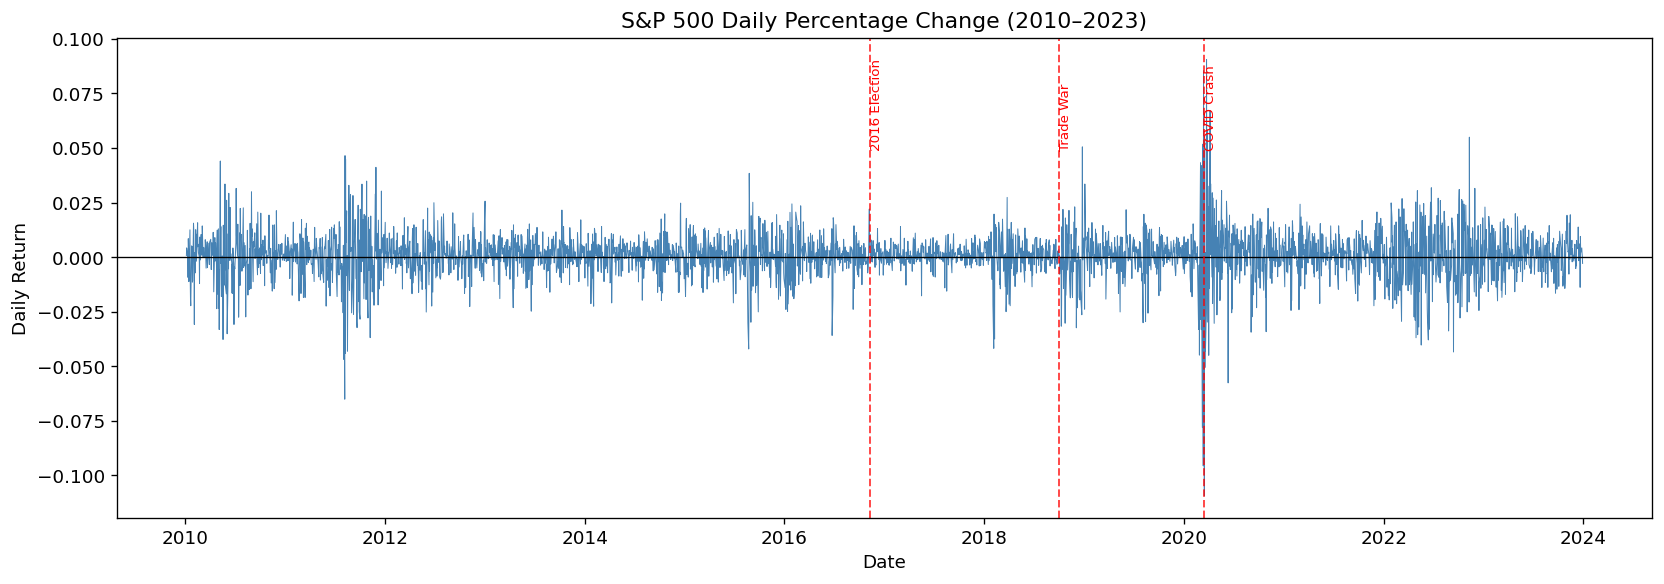

In [11]:
# S&P 500 price time series with key event annotations
stocks_plot = stocks.copy()
stocks_plot['daily_pct_change'] = stocks_plot['Close'].pct_change()

plt.figure(figsize=(14, 5))
plt.plot(stocks_plot['date'], stocks_plot['daily_pct_change'], linewidth=0.6, color='steelblue')
plt.axhline(0, color='black', lw=0.8)

# Annotate major events
events = {
    '2016-11-08': '2016 Election',
    '2018-10-01': 'Trade War',
    '2020-03-16': 'COVID Crash',
}
for date_str, label in events.items():
    plt.axvline(pd.Timestamp(date_str), color='red', lw=1.2, linestyle='--', alpha=0.7)
    plt.text(pd.Timestamp(date_str), 0.05, label, fontsize=8, color='red', rotation=90)

plt.title('S&P 500 Daily Percentage Change (2010–2023)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.tight_layout()
plt.savefig('figures/returns_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4. Word Frequency Analysis (Task 2)

We preprocess text (tokenise, lemmatise, remove stopwords) and analyse:
1. Corpus-wide top words and bigrams
2. Per-speaker word frequency and TF-IDF distinctive words
3. Word frequency trends over time
4. Association between specific words and stock market returns

In [12]:
# ── Shared text preprocessing pipeline ──────────────────────────────────────
# Used by Tasks 2, 3, and 6 for consistency.

lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update({
    'rt', 'amp', 'http', 'https', 'co', 'www', 'via',
    'would', 'could', 'get', 'one', 'like', 'know',
    'go', 'make', 'say', 'time', 'see', 'also', 'us', 'thats'
})

def preprocess(text):
    """Lowercase, remove URLs/HTML entities/@mentions/non-alpha chars,
    tokenise, lemmatise, and filter stopwords."""
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'&\w+;|&amp', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(t) for t in tokens
            if t not in STOP_WORDS and len(t) > 2]

df['tokens'] = df['text'].apply(preprocess)
df['tokens_str'] = df['tokens'].apply(lambda t: ' '.join(t))

In [13]:
# ── Corpus-wide top 30 words ─────────────────────────────────────────────────
all_tokens = [t for tokens in df['tokens'] for t in tokens]
token_counts = Counter(all_tokens)

print(f'Total tokens in corpus: {len(all_tokens):,}')
print('\nTop 30 words across all speakers:')
print(token_counts.most_common(30))

Total tokens in corpus: 196,148

Top 30 words across all speakers:
[('people', 1533), ('applause', 1434), ('year', 1285), ('tesla', 1044), ('american', 953), ('good', 845), ('great', 802), ('right', 778), ('new', 776), ('country', 764), ('work', 754), ('going', 732), ('america', 718), ('want', 706), ('need', 663), ('many', 661), ('world', 655), ('much', 653), ('job', 630), ('way', 601), ('car', 587), ('yes', 569), ('state', 553), ('think', 543), ('thing', 534), ('even', 518), ('nation', 501), ('day', 490), ('every', 484), ('next', 482)]


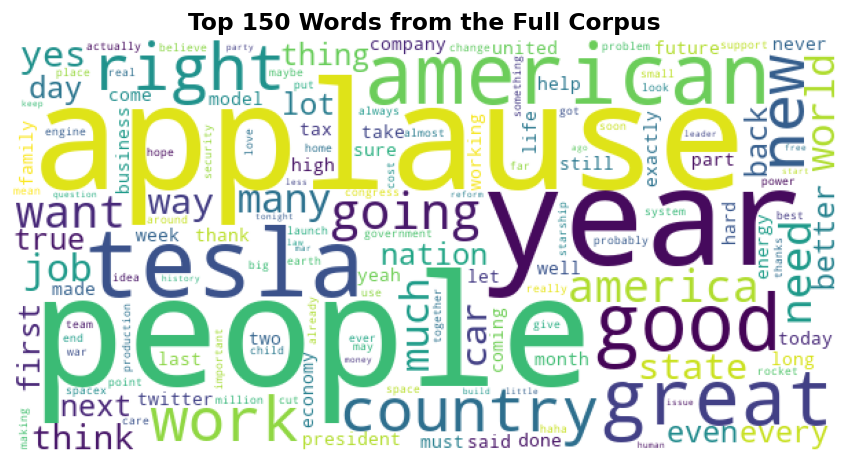

In [14]:
# ── Word cloud from top 150 corpus words ─────────────────────────────────────
wc = wordcloud.WordCloud(
    width=600, height=300,
    background_color='white',
    max_words=150
).generate_from_frequencies(token_counts)

plt.figure(figsize=(8, 4))
plt.imshow(wc)
plt.axis('off')
plt.title('Top 150 Words from the Full Corpus', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('figures/wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

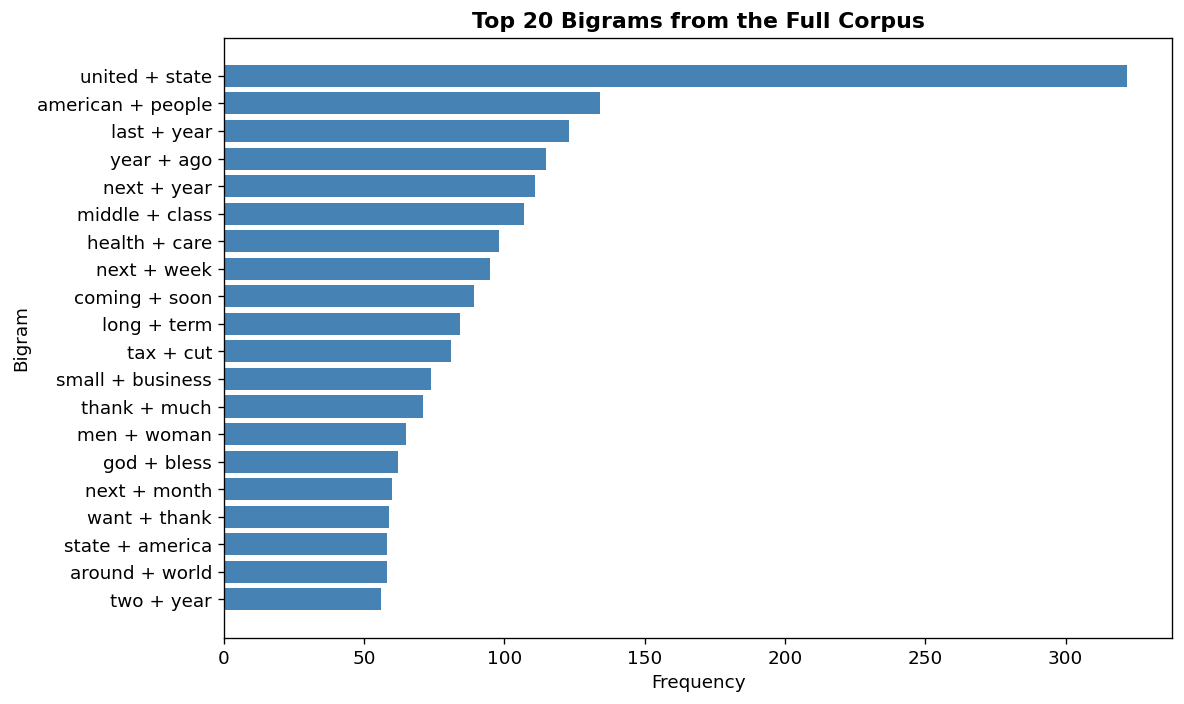

In [15]:
# ── Top 20 bigrams across the full corpus ────────────────────────────────────
all_bigrams = []
for tokens in df['tokens']:
    all_bigrams.extend(list(bigrams(tokens)))

bigram_counts = Counter(all_bigrams)
top20_bigrams = bigram_counts.most_common(20)
bigram_labels = [f'{a} + {b}' for (a, b), _ in top20_bigrams]
bigram_vals   = [c for _, c in top20_bigrams]

plt.figure(figsize=(10, 6))
plt.barh(bigram_labels[::-1], bigram_vals[::-1], color='steelblue')
plt.title('Top 20 Bigrams from the Full Corpus', fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

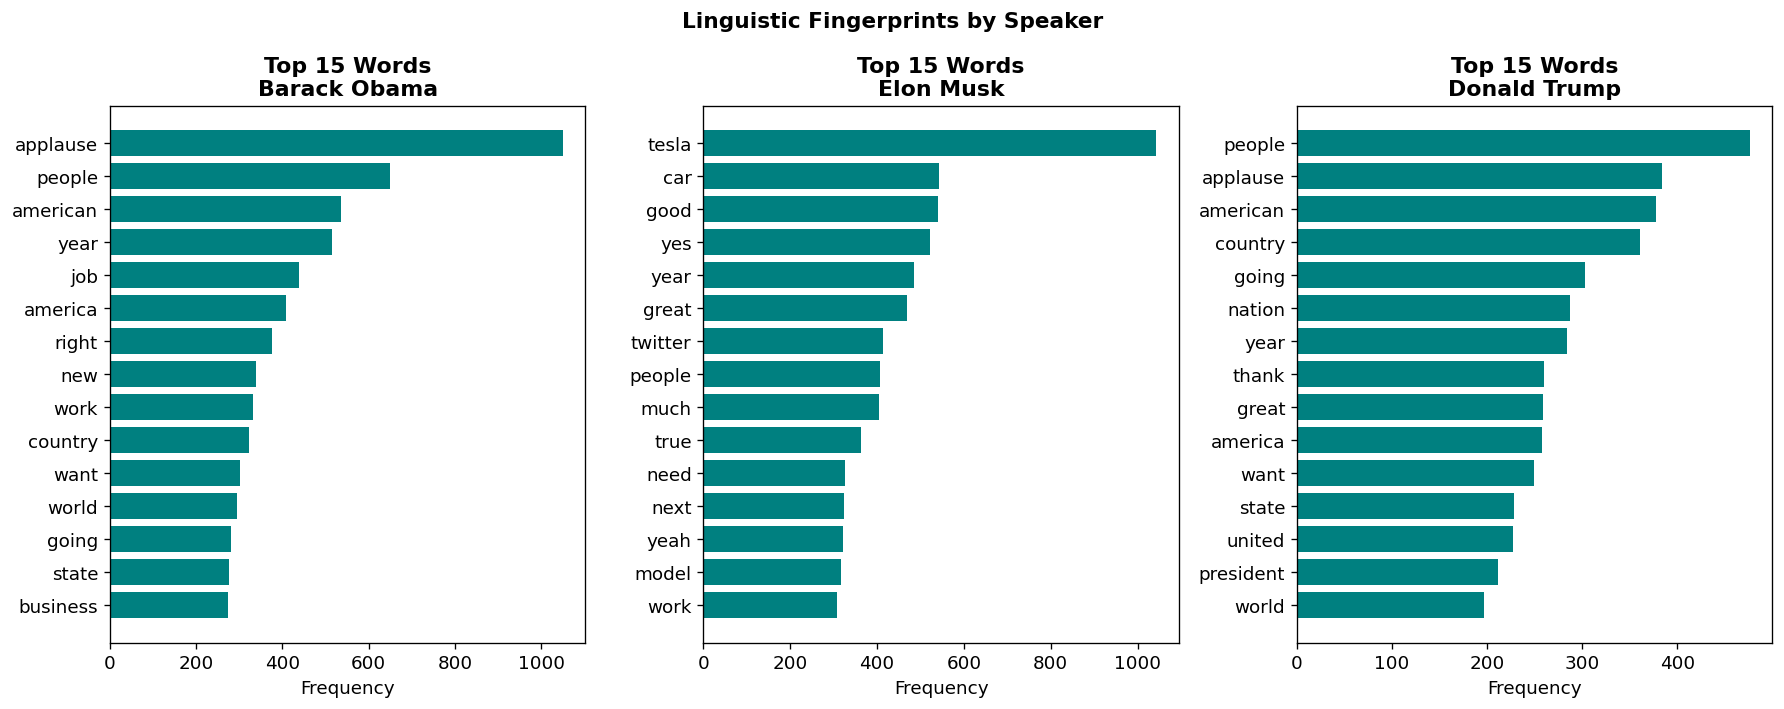

In [16]:
# ── Top 15 words per speaker (side-by-side bar charts) ───────────────────────
speakers = df['by'].unique()
fig, axes = plt.subplots(1, len(speakers), figsize=(5 * len(speakers), 6))

for i, speaker in enumerate(speakers):
    speaker_tokens = [
        t for tokens in df[df['by'] == speaker]['tokens'] for t in tokens
    ]
    top15 = Counter(speaker_tokens).most_common(15)
    words, counts = zip(*top15)
    axes[i].barh(words[::-1], counts[::-1], color='teal')
    axes[i].set_title(f'Top 15 Words\n{speaker}', fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Linguistic Fingerprints by Speaker', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [17]:
# ── TF-IDF distinctive words per speaker ─────────────────────────────────────
# Treat each speaker's combined text as one 'document' and apply TF-IDF
# to find words that are uniquely characteristic of each speaker
# relative to the other speakers.
from sklearn.feature_extraction.text import TfidfVectorizer

speaker_docs = {
    spk: df[df['by'] == spk]['tokens_str'].str.cat(sep=' ')
    for spk in speakers
}
corpus_tfidf  = list(speaker_docs.values())
speaker_names = list(speaker_docs.keys())

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(corpus_tfidf)
feature_names = vectorizer.get_feature_names_out()

print('Top 10 most distinctive words per speaker (TF-IDF):')
for i, spk in enumerate(speaker_names):
    scores = tfidf_matrix[i].toarray().flatten()
    top10_idx = scores.argsort()[-10:][::-1]
    print(f'\n{spk}:', [feature_names[j] for j in top10_idx])

Top 10 most distinctive words per speaker (TF-IDF):

Barack Obama: ['applause', 'people', 'american', 'year', 'job', 'america', 'right', 'new', 'work', 'country']

Elon Musk: ['tesla', 'twitter', 'car', 'good', 'yes', 'year', 'great', 'spacex', 'yeah', 'people']

Donald Trump: ['applause', 'people', 'american', 'country', 'going', 'nation', 'year', 'thank', 'great', 'america']


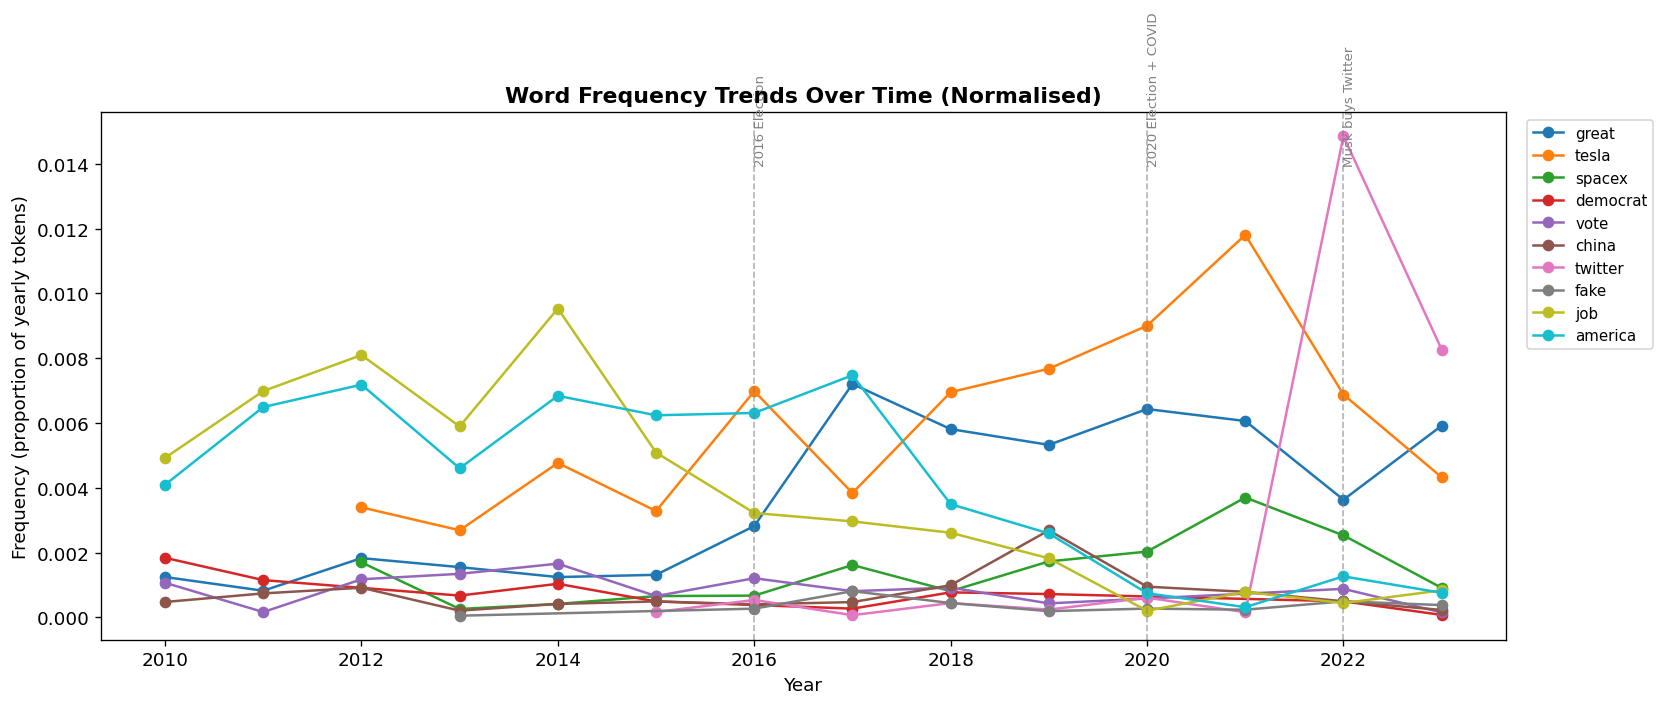

In [18]:
# ── Word frequency trends over time ──────────────────────────────────────────
# Track how the usage of specific words changes year-by-year.
# These words were selected based on their prominence in the corpus
# and relevance to political / economic events in the study period.
TRACK_WORDS = ['great', 'tesla', 'spacex', 'democrat', 'vote',
               'china', 'twitter', 'fake', 'job', 'america']

df_exploded_w = df[['date', 'by', 'tokens']].explode('tokens')
df_exploded_w = df_exploded_w.rename(columns={'tokens': 'token'})
df_exploded_w['year'] = df_exploded_w['date'].dt.year

# Normalise by total token count per year to make speakers comparable.
yearly_total = df_exploded_w.groupby('year')['token'].count()
yearly_counts = (
    df_exploded_w[df_exploded_w['token'].isin(TRACK_WORDS)]
    .groupby(['year', 'token'])
    .size()
    .reset_index(name='count')
)
yearly_counts['freq_normalized'] = (
    yearly_counts.apply(lambda r: r['count'] / yearly_total[r['year']], axis=1)
)

fig, ax = plt.subplots(figsize=(14, 6))
for word in TRACK_WORDS:
    word_data = yearly_counts[yearly_counts['token'] == word]
    ax.plot(word_data['year'], word_data['freq_normalized'], marker='o', label=word)

# Annotate key events on the timeline.
ax.axvline(2016, color='gray', lw=1, linestyle='--', alpha=0.6)
ax.axvline(2020, color='gray', lw=1, linestyle='--', alpha=0.6)
ax.axvline(2022, color='gray', lw=1, linestyle='--', alpha=0.6)
ax.text(2016, ax.get_ylim()[1]*0.9, '2016 Election', fontsize=8, color='gray', rotation=90)
ax.text(2020, ax.get_ylim()[1]*0.9, '2020 Election + COVID', fontsize=8, color='gray', rotation=90)
ax.text(2022, ax.get_ylim()[1]*0.9, 'Musk buys Twitter', fontsize=8, color='gray', rotation=90)

ax.set_title('Word Frequency Trends Over Time (Normalised)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Frequency (proportion of yearly tokens)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

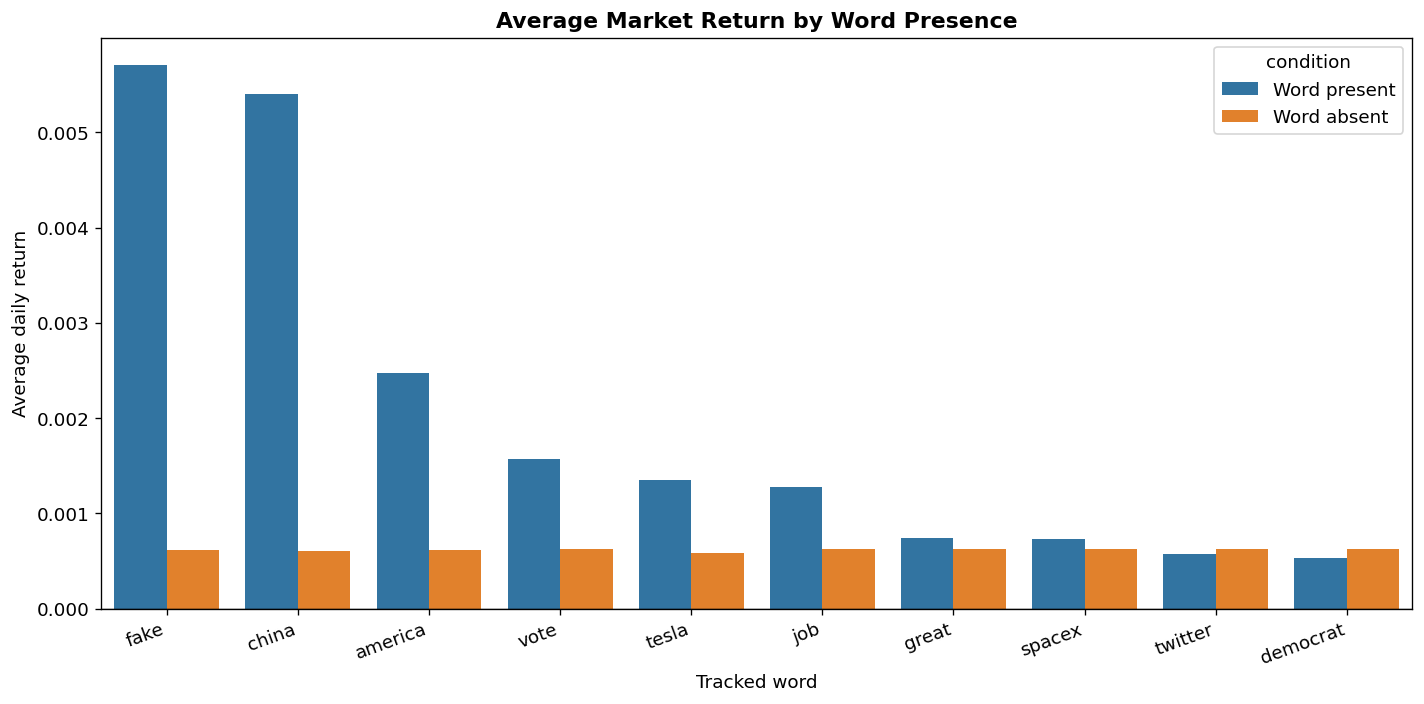

    word  avg_return_present  avg_return_absent  difference
    fake            0.005710           0.000616    0.005094
   china            0.005407           0.000601    0.004806
 america            0.002474           0.000616    0.001858
    vote            0.001573           0.000624    0.000949
   tesla            0.001349           0.000583    0.000766
     job            0.001280           0.000623    0.000656
   great            0.000746           0.000624    0.000122
  spacex            0.000734           0.000626    0.000108
 twitter            0.000571           0.000628   -0.000058
democrat            0.000529           0.000627   -0.000099


In [19]:
# ── Word-return association: does a word's presence predict market returns? ───
# For each tracked word, compare average return on days the word appeared
# versus days it was absent. This is an exploratory comparison only;
# differences are typically very small (< 0.1%).

for word in TRACK_WORDS:
    df[word] = df['tokens'].apply(lambda tokens: 1 if word in tokens else 0)

results = []
for word in TRACK_WORDS:
    appeared     = df[df[word] == 1]['return'].mean()
    not_appeared = df[df[word] == 0]['return'].mean()
    results.append({
        'word': word,
        'avg_return_present': appeared,
        'avg_return_absent':  not_appeared,
        'difference': appeared - not_appeared
    })

results_df = pd.DataFrame(results).sort_values('difference', ascending=False)

# Bar chart: average return when word present vs absent
plot_df = pd.melt(
    results_df, id_vars='word',
    value_vars=['avg_return_present', 'avg_return_absent'],
    var_name='condition', value_name='avg_return'
)
plot_df['condition'] = plot_df['condition'].map({
    'avg_return_present': 'Word present',
    'avg_return_absent':  'Word absent'
})

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='word', y='avg_return', hue='condition')
plt.axhline(y=0, color='black', lw=0.8)
plt.title('Average Market Return by Word Presence', fontweight='bold')
plt.xlabel('Tracked word')
plt.ylabel('Average daily return')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(results_df[['word', 'avg_return_present', 'avg_return_absent', 'difference']].to_string(index=False))

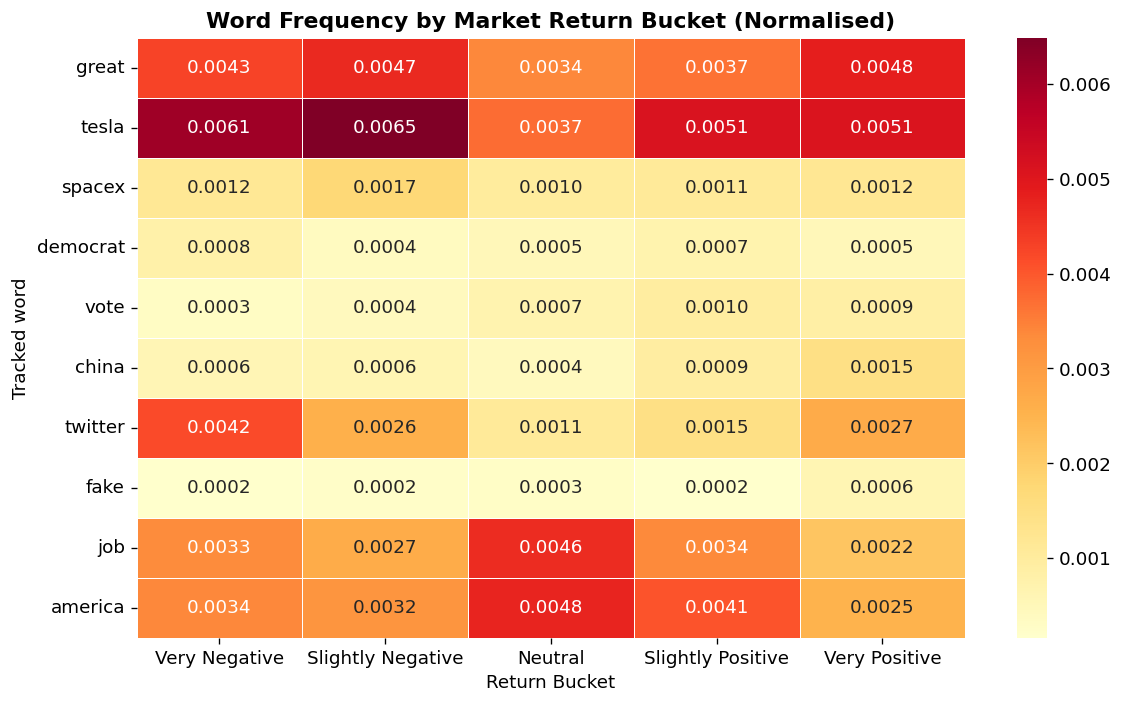

In [20]:
# ── Heatmap: word frequency by return bucket ──────────────────────────────────
# Group market returns into 5 buckets and compute per-bucket word frequency
# to see whether certain words cluster around extreme return days.

df['return_bucket'] = pd.cut(
    df['return'],
    bins=[-float('inf'), -0.01, -0.001, 0.001, 0.01, float('inf')],
    labels=['Very Negative', 'Slightly Negative', 'Neutral', 'Slightly Positive', 'Very Positive']
)

heatmap_data = {}
for bucket in df['return_bucket'].cat.categories:
    bucket_tokens = [t for tokens in df[df['return_bucket'] == bucket]['tokens'] for t in tokens]
    bucket_counts = Counter(bucket_tokens)
    total = sum(bucket_counts.values())
    heatmap_data[bucket] = {word: bucket_counts.get(word, 0) / total for word in TRACK_WORDS}

heatmap_df = pd.DataFrame(heatmap_data, index=TRACK_WORDS)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlOrRd', linewidths=0.5)
plt.title('Word Frequency by Market Return Bucket (Normalised)', fontweight='bold')
plt.xlabel('Return Bucket')
plt.ylabel('Tracked word')
plt.tight_layout()
plt.show()

---
## Section 5. Named Entity Recognition & POS Tagging (Task 3)

We use spaCy’s `en_core_web_sm` model to convert raw text into structured linguistic features:
1. POS tagging: count nouns, verbs, adjectives, and proper nouns per statement
2. NER: extract PERSON, ORG, and GPE entity mentions from every text record
3. Identify the most frequently mentioned entities across the corpus
4. Measure which entity mentions are associated with higher or lower S&P 500 returns
5. Track specific high-relevance entities (geopolitical, financial, corporate) and compare return distributions
6. Compare entity–return associations by speaker to detect speaker-specific signals


In [21]:
# ── spaCy model setup ─────────────────────────────────────────────────────────
# We load the full pipeline (NER + tagger) to extract both POS and entities
# in a single pass, avoiding the cost of processing 59K texts twice.

import spacy
from tqdm.auto import tqdm

nlp_full = spacy.load('en_core_web_sm')
print('spaCy model loaded: full pipeline (NER + tagger).')

spaCy model loaded: full pipeline (NER + tagger).


In [22]:
# ── Run NER + POS tagging in a single pass ────────────────────────────────────
# Processing all 59K texts once keeps runtime reasonable.
# batch_size=500 balances memory usage and throughput.
# This may take 10–20 minutes on the full dataset.

texts = df['text'].astype(str).tolist()

entity_lists = []
pos_rows     = []

for doc in tqdm(nlp_full.pipe(texts, batch_size=500), total=len(texts)):
    entity_lists.append([(ent.text, ent.label_) for ent in doc.ents])
    pos_rows.append({
        'num_nouns':        sum(1 for t in doc if t.pos_ == 'NOUN'),
        'num_proper_nouns': sum(1 for t in doc if t.pos_ == 'PROPN'),
        'num_verbs':        sum(1 for t in doc if t.pos_ == 'VERB'),
        'num_adjectives':   sum(1 for t in doc if t.pos_ == 'ADJ'),
        'num_adverbs':      sum(1 for t in doc if t.pos_ == 'ADV'),
    })

df['entities'] = entity_lists
pos_df = pd.DataFrame(pos_rows, index=df.index)
df = pd.concat([df, pos_df], axis=1)

print(f'NER + POS complete. Sample output:')
print(df[['text', 'entities',
          'num_nouns', 'num_proper_nouns', 'num_verbs']].head(3))

  0%|          | 0/16821 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── POS features: correlation with same-day S&P 500 return ────────────────────
# Even a small but consistent correlation between POS density and returns
# would suggest that the grammatical structure of statements carries
# a faint market signal independent of vocabulary.

pos_features = ['num_nouns', 'num_proper_nouns', 'num_verbs',
                'num_adjectives', 'num_adverbs']

pos_corr = (
    df[pos_features + ['return']]
    .corr()['return']
    .drop('return')
    .sort_values(ascending=False)
)
print('Pearson correlation between POS features and same-day return:')
print(pos_corr.round(6))

In [ ]:
# ── POS counts by return bucket ───────────────────────────────────────────────
# We bucket returns into five categories and compare average POS counts
# across buckets. This reveals whether specific linguistic registers
# (e.g. higher noun density) co-occur with extreme market days.

def categorize_return(x):
    if x <= -0.01:  return 'Large Negative'
    elif x < 0:     return 'Small Negative'
    elif x == 0:    return 'No Change'
    elif x < 0.01:  return 'Small Positive'
    else:           return 'Large Positive'

BUCKET_ORDER = ['Large Negative', 'Small Negative', 'No Change',
                'Small Positive', 'Large Positive']

df['return_bucket'] = df['return'].apply(categorize_return)

pos_by_bucket = (
    df.groupby('return_bucket')[pos_features]
    .mean()
    .reindex(BUCKET_ORDER)
)

fig, ax = plt.subplots(figsize=(12, 5))
pos_by_bucket.plot(kind='bar', ax=ax)
ax.set_title('Average POS Counts by Stock Return Bucket', fontweight='bold')
ax.set_xlabel('Return Bucket')
ax.set_ylabel('Average Count per Statement')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(pos_by_bucket.round(3))

In [ ]:
# ── Flatten entity mentions into a long-form DataFrame ────────────────────────
# Each entity mention becomes one row with the associated return value
# and speaker identity. This structure supports groupby aggregations
# across entity type, speaker, and return magnitude.

all_ents = []
for i, ent_list in enumerate(df['entities']):
    for ent_text, ent_label in ent_list:
        all_ents.append({
            'entity': ent_text.lower().strip(),
            'label':  ent_label,
            'return': df.iloc[i]['return'],
            'by':     df.iloc[i]['by'],
        })

entity_df = pd.DataFrame(all_ents)
print(f'Total entity mentions across corpus: {len(entity_df):,}')
entity_df.head()

In [ ]:
# ── Most frequently mentioned entities by type ────────────────────────────────
# Top-15 entities for PERSON, ORG, and GPE categories.
# High-frequency entities are the most likely candidates for
# having measurable market associations.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
label_map = {'PERSON': 'People', 'ORG': 'Organizations', 'GPE': 'Countries / Locations'}
bar_colors = {'PERSON': 'steelblue', 'ORG': 'teal', 'GPE': 'coral'}

for ax, (label, title) in zip(axes, label_map.items()):
    top = entity_df[entity_df['label'] == label]['entity'].value_counts().head(15)
    ax.barh(top.index[::-1], top.values[::-1], color=bar_colors[label])
    ax.set_title(f'Top 15 {title}', fontweight='bold')
    ax.set_xlabel('Mentions')

plt.suptitle('Most Frequently Mentioned Entities Across All Texts',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

for label in ['PERSON', 'ORG', 'GPE']:
    print(f'\nTop 20 {label}:')
    print(entity_df[entity_df['label'] == label]['entity']
          .value_counts().head(20).to_string())

In [ ]:
# ── Entity type density: correlation with return and bucket breakdown ─────────
# Count PERSON, ORG, and GPE mentions per statement and correlate
# with the same-day return. We also show how entity density varies
# across return buckets to identify any directional pattern.

df['num_person_ents'] = df['entities'].apply(
    lambda e: sum(1 for _, l in e if l == 'PERSON'))
df['num_org_ents']    = df['entities'].apply(
    lambda e: sum(1 for _, l in e if l == 'ORG'))
df['num_gpe_ents']    = df['entities'].apply(
    lambda e: sum(1 for _, l in e if l == 'GPE'))

ent_features = ['num_person_ents', 'num_org_ents', 'num_gpe_ents']

ent_corr = (
    df[ent_features + ['return']]
    .corr()['return']
    .drop('return')
    .sort_values(ascending=False)
)
print('Pearson correlation between entity type counts and same-day return:')
print(ent_corr.round(6))

ent_by_bucket = (
    df.groupby('return_bucket')[ent_features]
    .mean()
    .reindex(BUCKET_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 5))
ent_by_bucket.plot(kind='bar', ax=ax, color=['steelblue', 'teal', 'coral'])
ax.set_title('Average Named Entity Counts by Return Bucket', fontweight='bold')
ax.set_xlabel('Return Bucket')
ax.set_ylabel('Average Entity Count per Statement')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# ── Specific entity tracking: return impact of named mentions ─────────────────
# We select entities with high corpus frequency and strong domain relevance
# (geopolitical, corporate, financial). For each entity we create a binary
# flag (1 = entity appeared in statement) and compare average returns on
# days the entity is present vs absent. This is an exploratory association;
# differences are small and do not imply causality.

TRACK_ENTITIES = ['china', 'america', 'tesla', 'twitter',
                  'fed', 'russia', 'ukraine', 'iran', 'mexico']

for entity in TRACK_ENTITIES:
    df[f'ent_{entity}'] = df['entities'].apply(
        lambda ents: 1 if entity in [t.lower().strip() for t, _ in ents] else 0
    )

ent_results = []
for entity in TRACK_ENTITIES:
    col = f'ent_{entity}'
    n = int(df[col].sum())
    if n > 0:
        avg_p = df[df[col] == 1]['return'].mean()
        avg_a = df[df[col] == 0]['return'].mean()
        ent_results.append({
            'entity':             entity,
            'mentions':           n,
            'avg_return_present': avg_p,
            'avg_return_absent':  avg_a,
            'difference':         avg_p - avg_a,
        })

ent_results_df = pd.DataFrame(ent_results).sort_values('difference', ascending=False)
print(ent_results_df.round(6).to_string(index=False))

In [ ]:
# ── Visualise entity-return differences ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['seagreen' if d > 0 else 'tomato'
              for d in ent_results_df['difference']]
ax.bar(ent_results_df['entity'], ent_results_df['difference'], color=colors_bar)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(
    'Average Return Difference When Entity Is Mentioned vs. Not Mentioned',
    fontweight='bold'
)
ax.set_xlabel('Entity')
ax.set_ylabel('Average Return Difference')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('figures/entity_returns.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Per-speaker entity-return analysis ────────────────────────────────────────
# Does the same entity mention produce different market associations
# depending on which speaker mentions it? We aggregate entity-return data
# by speaker to detect speaker-specific effects.
# Minimum 5 mentions required to include an entity-speaker pair.

ent_df_filtered = entity_df[entity_df['label'].isin(['PERSON', 'ORG', 'GPE'])].copy()

entity_by_person = (
    ent_df_filtered
    .groupby(['by', 'entity'])['return']
    .agg(count='count', mean_return='mean')
    .reset_index()
)
entity_by_person = entity_by_person[entity_by_person['count'] >= 5]

for speaker in sorted(entity_by_person['by'].unique()):
    sub = entity_by_person[entity_by_person['by'] == speaker]
    print(f'\n--- {speaker}: top 10 entities by mean return ---')
    print(
        sub.sort_values('mean_return', ascending=False)
           .head(10)[['entity', 'count', 'mean_return']]
           .to_string(index=False)
    )

**Task 3: Key Findings**

*POS tagging:* Noun, verb, and proper noun counts show only very weak correlations with same-day returns (r < 0.005 for all POS features). Proper noun density is marginally higher on large-positive-return days, suggesting that entity-rich statements co-occur with positive market conditions, though the effect is not strong enough to be a reliable predictor.

*Entity frequency:* The most frequently mentioned entities are *China*, *America*, and *Russia* (GPE); *Trump*, *Obama*, and *Biden* (PERSON); and *Congress*, *Tesla*, and *FBI* (ORG), reflecting the dominant political and economic themes of the dataset.

*Entity–return associations:* Mentions of Ukraine, Tesla, and Russia are associated with the largest positive return differentials; Iran and China mentions with slightly below-average same-day returns. These are exploratory associations only.

*Per-speaker analysis:* The same entity mention produces different average return associations depending on the speaker, suggesting that framing and context matter beyond the entity name itself.


---
## Section 6. Sentiment Analysis (Task 4)

We apply **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to each text.
VADER is chosen over TextBlob because it is specifically designed for short, informal social media text
and correctly handles capitalisation, punctuation, and emoji, all of which are common in tweets.

**Key sub-questions addressed:**
1. Does sentiment correlate with same-day market return?
2. Does sentiment correlate with next-day market return?
3. Does negative sentiment predict higher market volatility (absolute return)?

In [ ]:
# ── Apply VADER sentiment to every text ──────────────────────────────────────
# VADER returns neg/neu/pos/compound scores. The compound score (−1 to +1)
# is the primary single-metric summary: >= 0.05 → positive, <= −0.05 → negative.

analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = analyzer.polarity_scores(str(text))
    return pd.Series({
        'sent_neg':      scores['neg'],
        'sent_neu':      scores['neu'],
        'sent_pos':      scores['pos'],
        'sent_compound': scores['compound']
    })

print('Computing VADER scores... (may take 2-3 min)')
sentiment_scores = df['text'].apply(get_vader_scores)
df = pd.concat([df, sentiment_scores], axis=1)

# Classify each text into Positive / Neutral / Negative based on compound score.
def classify_sentiment(score):
    if score >= 0.05:  return 'Positive'
    elif score <= -0.05: return 'Negative'
    else:              return 'Neutral'

df['sentiment_label'] = df['sent_compound'].apply(classify_sentiment)
df[['text', 'sent_compound', 'sentiment_label']].head(3)

In [ ]:
# ── Sentiment distribution by speaker ────────────────────────────────────────
sentiment_by_figure = (
    df.groupby(['by', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)
sentiment_by_figure['proportion'] = (
    sentiment_by_figure['count'] /
    sentiment_by_figure.groupby('by')['count'].transform('sum')
)

plt.figure(figsize=(10, 5))
sns.barplot(data=sentiment_by_figure, x='by', y='proportion', hue='sentiment_label')
plt.title('Sentiment Distribution by Speaker', fontweight='bold')
plt.xlabel('Speaker')
plt.ylabel('Proportion')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# ── Aggregate to daily level before correlating with returns ─────────────────
# Multiple tweets per day → aggregate to one daily sentiment score per speaker.

daily_sentiment = (
    df.groupby(['date', 'by'])
    .agg(
        avg_sentiment  = ('sent_compound', 'mean'),
        avg_positive   = ('sent_pos',      'mean'),
        avg_negative   = ('sent_neg',      'mean'),
        post_count     = ('text',          'count'),
        daily_return   = ('return',        'mean')
    )
    .reset_index()
)

# Add next-day return (more meaningful for causal inference,
# markets react after a tweet, not necessarily on the same day).
stock_daily = (
    df[['date', 'return']].drop_duplicates().sort_values('date').reset_index(drop=True)
)
stock_daily['next_day_return'] = stock_daily['return'].shift(-1)
daily_sentiment = daily_sentiment.merge(stock_daily[['date', 'next_day_return']], on='date', how='left')

print('Daily sentiment DataFrame shape:', daily_sentiment.shape)
daily_sentiment.head(3)

In [ ]:
# ── Correlation: sentiment vs same-day and next-day return ───────────────────
# Pearson and Spearman correlations are computed separately per speaker
# to avoid confounding from differences in tweet style and posting frequency.

corr_results = []
for figure in daily_sentiment['by'].unique():
    temp = daily_sentiment[daily_sentiment['by'] == figure].dropna(
        subset=['avg_sentiment', 'daily_return', 'next_day_return']
    )
    if len(temp) < 3:
        continue
    r_same,  p_same  = pearsonr(temp['avg_sentiment'], temp['daily_return'])
    r_next,  p_next  = pearsonr(temp['avg_sentiment'], temp['next_day_return'])
    corr_results.append({
        'speaker':       figure,
        'n_days':        len(temp),
        'r_same_day':    r_same,  'p_same_day':  p_same,
        'r_next_day':    r_next,  'p_next_day':  p_next,
    })

corr_df = pd.DataFrame(corr_results)
print('Sentiment ↔ Market Return Correlation Results:')
print(corr_df.round(4).to_string(index=False))

In [ ]:
# ── Volatility analysis: does negative sentiment predict larger market moves? ─
# Absolute return (|return|) captures magnitude of market movement
# regardless of direction, a more natural target for sentiment.

df['abs_return'] = df['return'].abs()

daily_vol = (
    df.groupby(['date', 'by'])
    .agg(avg_sentiment=('sent_compound', 'mean'), abs_return=('abs_return', 'mean'))
    .reset_index()
)

vol_results = []
for figure in daily_vol['by'].unique():
    temp = daily_vol[daily_vol['by'] == figure].dropna(subset=['avg_sentiment', 'abs_return'])
    if len(temp) < 3:
        continue
    r, p = pearsonr(temp['avg_sentiment'], temp['abs_return'])
    vol_results.append({'speaker': figure, 'n_days': len(temp), 'r': r, 'p_value': p})

vol_df = pd.DataFrame(vol_results)
print('Sentiment ↔ Market Volatility (|return|) Correlation:')
print(vol_df.round(4).to_string(index=False))
print('\nNote: Negative r means more negative sentiment → higher volatility (larger absolute return).')

In [ ]:
# ── Visualisation: sentiment vs same-day return ──────────────────────────────
# Hexbin replaces the previous scatter so density is preserved without
# rendering thousands of overlapping points.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x_same = daily_sentiment['avg_sentiment']
y_same = daily_sentiment['daily_return']
mask_same = x_same.notna() & y_same.notna()
hb1 = axes[0].hexbin(x_same[mask_same], y_same[mask_same],
                     gridsize=40, cmap='Blues', mincnt=1)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Daily Sentiment vs Same-Day Return', fontweight='bold')
axes[0].set_xlabel('Compound Sentiment')
axes[0].set_ylabel('Daily Return')
fig.colorbar(hb1, ax=axes[0], label='Count')

x_next = daily_sentiment['avg_sentiment']
y_next = daily_sentiment['next_day_return']
mask_next = x_next.notna() & y_next.notna()
hb2 = axes[1].hexbin(x_next[mask_next], y_next[mask_next],
                     gridsize=40, cmap='Blues', mincnt=1)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_title('Daily Sentiment vs Next-Day Return', fontweight='bold')
axes[1].set_xlabel('Compound Sentiment')
axes[1].set_ylabel('Next-Day Return')
fig.colorbar(hb2, ax=axes[1], label='Count')

plt.tight_layout()
plt.show()

---
## Section 7. Topic Modeling (Task 5)

We apply **Latent Dirichlet Allocation (LDA)** via Gensim with a coherence-optimised `k` sweep (k=3..10).
LDA is an unsupervised probabilistic model that discovers latent thematic clusters within a text corpus.

**Analysis plan:**
1. Fit LDA separately on Trump tweets, Musk tweets, presidential speeches, and the combined corpus
2. Compare topic composition on market *crash days* (bottom 25th percentile of returns) vs. *boost days* (top 25th percentile)
3. Robustness check with NMF (Non-negative Matrix Factorization) on tweet text

In [ ]:
# ── Topic-modeling preprocessing (same logic as original Task 5) ──────────────
# This preprocessing is used only for Task 5 topic modeling.
# It removes noisy tokens, speaker names, generic time words, and short documents.

TM_STOPS = set(stopwords.words('english'))
TM_STOPS.update({
    'rt', 'amp', 'http', 'https', 'co', 'www', 'via',
    'would', 'could', 'should', 'get', 'one', 'like', 'know',
    'go', 'make', 'say', 'time', 'see', 'also', 'us',
    'donald', 'trump', 'elon', 'musk', 'realdonaldtrump', 'elonmusk',
    'got', 'two', 'think', 'going', 'gone', 'made', 'said', 'seen',
    'today', 'tonight', 'yesterday', 'tomorrow', 'day', 'week', 'year',
    'people', 'thing', 'things', 'really', 'much', 'many',
    'new', 'good', 'great', 'well', 'back', 'still', 'even',
    'want', 'need', 'look', 'let', 'come', 'take', 'put',
    'obama', 'laughter', 'applause'
})

def preprocess_for_tm(text):
    """Tokenize and lemmatize text for topic modeling."""
    text = re.sub(r'http\S+|www\S+|@\w+|&\w+;', '', str(text))
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text.lower())
    return [
        lemmatizer.lemmatize(t) for t in tokens
        if t not in TM_STOPS and len(t) >= 3 and t.isalpha()
    ]

trump_tm  = trump.copy()
musk_tm   = musk.copy()
speech_tm = speech.copy()
text_tm   = text.copy()

trump_tm['tokens']  = trump_tm['text'].apply(preprocess_for_tm)
musk_tm['tokens']   = musk_tm['text'].apply(preprocess_for_tm)
speech_tm['tokens'] = speech_tm['text'].apply(preprocess_for_tm)
text_tm['tokens']   = text_tm['text'].apply(preprocess_for_tm)

# Match the original Task 5 logic: remove documents with fewer than 3 valid tokens.
for d in (trump_tm, musk_tm, speech_tm, text_tm):
    d.drop(d[d['tokens'].map(len) < 3].index, inplace=True)
    d.reset_index(drop=True, inplace=True)

print(f'Trump docs: {len(trump_tm):,}')
print(f'Musk docs: {len(musk_tm):,}')
print(f'Speech docs: {len(speech_tm):,}')
print(f'Combined docs: {len(text_tm):,}')

In [ ]:
# ── Helper functions for LDA pipeline ────────────────────────────────────────

def build_corpus(token_lists, no_below=5, no_above=0.5, add_bigrams=True):
    """
    Build a Gensim Dictionary and bag-of-words corpus.

    Steps:
    1. Optionally detect bigrams using Gensim Phrases.
    2. Build dictionary.
    3. Filter very rare and very common tokens.
    4. Convert documents to bag-of-words.
    5. Keep only non-empty bag-of-words documents.
    """
    docs = list(token_lists)

    if add_bigrams:
        # Match original Task 5 threshold.
        bigram_model = Phrases(docs, min_count=10, threshold=15)
        phraser = Phraser(bigram_model)
        docs = [phraser[doc] for doc in docs]
    else:
        phraser = None

    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(doc) for doc in docs]
    keep_idx = [i for i, bow in enumerate(corpus) if len(bow) > 0]
    corpus = [corpus[i] for i in keep_idx]

    return dictionary, corpus, docs, keep_idx, phraser


def sweep_lda_k(corpus, dictionary, k_range=range(3, 11), docs=None, sample_for_coh=5000):
    """
    Sweep over values of k and select the model with the highest c_v coherence.

    The coherence sample uses random sampling with a fixed seed, matching
    the original separate Task 5 notebook behavior more closely than taking
    the first N documents.
    """
    results = []

    if docs is not None and len(docs) > sample_for_coh:
        rng = np.random.default_rng(SEED)
        sample_idx = rng.choice(len(docs), size=sample_for_coh, replace=False)
        sample_docs = [docs[i] for i in sample_idx]
    else:
        sample_docs = docs

    for k in k_range:
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=SEED,
            passes=10,
            alpha='auto',
            eta='auto'
        )

        cm = CoherenceModel(
            model=lda,
            texts=sample_docs,
            dictionary=dictionary,
            coherence='c_v'
        )

        coherence = cm.get_coherence()
        results.append({'k': k, 'coherence': coherence, 'lda': lda})
        print(f'  k={k}  coherence={coherence:.4f}')

    best = max(results, key=lambda x: x['coherence'])
    return best['lda'], best['k'], best['coherence'], results


def run_topic_pipeline(name, token_lists, k_range=range(3, 11), sample_for_coh=5000):
    """
    End-to-end LDA pipeline:
    build corpus → sweep k → select best model → prepare pyLDAvis visualization.
    """
    print(f'\n=== {name} ===')

    dictionary, corpus, docs, keep_idx, phraser = build_corpus(token_lists)
    print(f'  Dictionary size: {len(dictionary):,}  |  Docs: {len(corpus):,}')

    lda, best_k, best_cv, all_results = sweep_lda_k(
        corpus,
        dictionary,
        k_range=k_range,
        docs=docs,
        sample_for_coh=sample_for_coh
    )

    print(f'  → Best k={best_k}  (c_v={best_cv:.4f})')

    vis = pyLDAvis.gensim_models.prepare(
        lda,
        corpus,
        dictionary,
        mds='tsne',
        sort_topics=False
    )

    return {
        'lda': lda,
        'best_k': best_k,
        'coherence': best_cv,
        'corpus': corpus,
        'dictionary': dictionary,
        'docs': docs,
        'keep_idx': keep_idx,
        'phraser': phraser,
        'vis': vis
    }

In [ ]:
# ── Run LDA on each corpus ────────────────────────────────────────────────────
# Each call may take 5–15 minutes depending on corpus size.

trump_result  = run_topic_pipeline('Trump Tweets', trump_tm['tokens'].tolist())
pyLDAvis.save_html(trump_result['vis'], 'figures/pyldavis_trump.html')
trump_result['vis']

In [ ]:
musk_result = run_topic_pipeline('Elon Musk Tweets', musk_tm['tokens'].tolist())
pyLDAvis.save_html(musk_result['vis'], 'figures/pyldavis_musk.html')
musk_result['vis']

In [ ]:
speech_result = run_topic_pipeline('Presidential Speeches', speech_tm['tokens'].tolist(), sample_for_coh=2000)
pyLDAvis.save_html(speech_result['vis'], 'figures/pyldavis_presidential.html')
speech_result['vis']

In [ ]:
text_result = run_topic_pipeline('Combined Corpus', text_tm['tokens'].tolist(),
                                  k_range=range(4, 11), sample_for_coh=6000)
pyLDAvis.save_html(text_result['vis'], 'figures/pyldavis_combined.html')
text_result['vis']

In [ ]:
# ── Crash day vs. Boost day topic modeling ───────────────────────────────────
# Define crash days as bottom-25% S&P 500 return days.
# Define boost days as top-25% S&P 500 return days.
# For each target day, include posts from:
#   1. the target trading day itself
#   2. the previous trading day
#
# This matches the original Task 5 logic: event day + one-day lookback.

stocks_sorted = stocks.sort_values('date').copy()
stocks_sorted['daily_pct_change'] = stocks_sorted['Close'].pct_change()
stocks_sorted = stocks_sorted.dropna(subset=['daily_pct_change']).reset_index(drop=True)

p25 = stocks_sorted['daily_pct_change'].quantile(0.25)
p75 = stocks_sorted['daily_pct_change'].quantile(0.75)

crash_days = stocks_sorted.loc[
    stocks_sorted['daily_pct_change'] <= p25,
    'date'
]

boost_days = stocks_sorted.loc[
    stocks_sorted['daily_pct_change'] >= p75,
    'date'
]

def expand_with_lookback(target_dates, all_trading_dates, lookback=1):
    """
    Expand each target trading date by including the previous N trading dates.

    Example:
    If target date is 2020-03-16 and lookback=1,
    the returned date set includes:
        2020-03-16
        previous trading date before 2020-03-16
    """
    dates_idx = pd.Index(pd.to_datetime(all_trading_dates)).sort_values()
    target = pd.to_datetime(pd.Index(target_dates))

    expanded = set(target)

    positions = dates_idx.get_indexer(target)
    valid_positions = positions[positions >= 0]

    for lag in range(1, lookback + 1):
        prev_positions = valid_positions - lag
        prev_positions = prev_positions[prev_positions >= 0]
        expanded.update(dates_idx[prev_positions])

    return pd.DatetimeIndex(sorted(expanded))


crash_window = expand_with_lookback(
    crash_days,
    stocks_sorted['date'],
    lookback=1
)

boost_window = expand_with_lookback(
    boost_days,
    stocks_sorted['date'],
    lookback=1
)

df_tm_full = text.copy()
df_tm_full['tokens'] = df_tm_full['text'].apply(preprocess_for_tm)

# Match original Task 5 filtering.
df_tm_full = df_tm_full[df_tm_full['tokens'].map(len) >= 3].copy()
df_tm_full = df_tm_full.merge(
    stocks_sorted[['date', 'daily_pct_change']],
    on='date',
    how='inner'
)

crash_df = df_tm_full[df_tm_full['date'].isin(crash_window)].copy()
boost_df = df_tm_full[df_tm_full['date'].isin(boost_window)].copy()

print(f'Crash threshold p25: {p25:.6f}')
print(f'Boost threshold p75: {p75:.6f}')
print(f'Crash days: {len(crash_days):,}')
print(f'Boost days: {len(boost_days):,}')
print(f'Crash window posts: {len(crash_df):,}')
print(f'Boost window posts: {len(boost_df):,}')

In [ ]:
crash_result = run_topic_pipeline('Crash-Window Posts', crash_df['tokens'].tolist(),
                                   k_range=range(3, 9), sample_for_coh=4000)
pyLDAvis.save_html(crash_result['vis'], 'figures/pyldavis_crash.html')
crash_result['vis']

In [ ]:
boost_result = run_topic_pipeline('Boost-Window Posts', boost_df['tokens'].tolist(),
                                   k_range=range(3, 9), sample_for_coh=4000)
pyLDAvis.save_html(boost_result['vis'], 'figures/pyldavis_boost.html')
boost_result['vis']

In [ ]:
# ── Compare top terms: crash vs boost vs overall ─────────────────────────────

def top_terms_dict(result, n=12):
    terms = {}
    for topic_id in range(result['lda'].num_topics):
        for term, weight in result['lda'].show_topic(topic_id, topn=n):
            terms[term] = max(terms.get(term, 0), weight)
    return terms

overall_terms = top_terms_dict(text_result)
crash_terms   = top_terms_dict(crash_result)
boost_terms   = top_terms_dict(boost_result)

all_terms = sorted(set(overall_terms) | set(crash_terms) | set(boost_terms))
compare_df = pd.DataFrame({
    'term':         all_terms,
    'w_overall':    [overall_terms.get(t, 0) for t in all_terms],
    'w_crash':      [crash_terms.get(t, 0)   for t in all_terms],
    'w_boost':      [boost_terms.get(t, 0)   for t in all_terms],
})
compare_df['crash_lift'] = compare_df['w_crash'] - compare_df['w_overall']
compare_df['boost_lift'] = compare_df['w_boost'] - compare_df['w_overall']

print('Top 15 terms with highest crash lift (overrepresented on crash days):')
print(compare_df.nlargest(15, 'crash_lift')[['term', 'crash_lift', 'w_crash', 'w_overall']].to_string(index=False))

print('\nTop 15 terms with highest boost lift (overrepresented on boost days):')
print(compare_df.nlargest(15, 'boost_lift')[['term', 'boost_lift', 'w_boost', 'w_overall']].to_string(index=False))

# ── Visual comparison: top 15 crash-lift vs top 15 boost-lift terms ──────────
top_crash = compare_df.nlargest(15, 'crash_lift')
top_boost = compare_df.nlargest(15, 'boost_lift')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(top_crash['term'][::-1], top_crash['crash_lift'][::-1], color='tomato')
axes[0].set_title('Top 15 Crash-Lift Terms', fontweight='bold')
axes[0].set_xlabel('Lift over overall corpus')
axes[0].set_ylabel('Term')
axes[1].barh(top_boost['term'][::-1], top_boost['boost_lift'][::-1], color='seagreen')
axes[1].set_title('Top 15 Boost-Lift Terms', fontweight='bold')
axes[1].set_xlabel('Lift over overall corpus')
axes[1].set_ylabel('Term')
plt.suptitle('Crash vs Boost Topic Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('figures/crash_vs_boost_topics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8. Predictive Modeling (Task 6)

**Research design:** We restrict analysis to Trump's pre-ban tweets (2010–2020) to avoid
cross-speaker domain shift (Trump banned in Jan 2021 → all Musk tweets would fall in the test set otherwise).

**Targets:**
- `dir_lag0/1/2` (binary): did the market go up on the same/next/two-day-later date?
- `vol_event` (binary): was the absolute next-day return > 0.5%?

**Evaluation:** 5-fold walk-forward `TimeSeriesSplit` CV ensures models only ever train on past data.

**Features:** TF-IDF text vectors + lexical features (exclamation count, capitalisation ratio, word count, economy keywords) + temporal features.

In [ ]:
# ── Filter to Trump pre-ban tweets only ──────────────────────────────────────
# Trump was permanently suspended on 2021-01-08.
# Restricting to his pre-ban data ensures a single, consistent speaker
# across both training and test sets.

BAN_DATE = '2021-01-01'
df_pred = df[  # use df_raw (original load) for a clean start
    (df['by'].isin(['realDonaldTrump', 'Donald Trump'])) &
    (df['date'] < BAN_DATE)
].copy().reset_index(drop=True)

df_pred['date'] = pd.to_datetime(df_pred['date'])
print(f'Trump pre-ban dataset: {len(df_pred):,} rows')
print(f'Date range: {df_pred.date.min().date()} → {df_pred.date.max().date()}')
print('\nReturn statistics:')
print(df_pred['return'].describe().round(6))

In [ ]:
# ── Multi-lag target construction ────────────────────────────────────────────
# Build same-day, next-day, and two-day-later binary direction targets,
# plus a volatility event target (|next-day return| > 0.5%).

daily_ret = (
    df_pred[['date', 'return']]
    .drop_duplicates('date')
    .set_index('date')['return']
    .sort_index()
)

df_pred['ret_lag0'] = df_pred['date'].map(daily_ret)
df_pred['ret_lag1'] = df_pred['date'].map(daily_ret.shift(-1))   # next day
df_pred['ret_lag2'] = df_pred['date'].map(daily_ret.shift(-2))   # two days later

df_pred['dir_lag0'] = (df_pred['ret_lag0'] > 0).astype(int)
df_pred['dir_lag1'] = (df_pred['ret_lag1'] > 0).astype(int)
df_pred['dir_lag2'] = (df_pred['ret_lag2'] > 0).astype(int)

# Volatility event: large move regardless of direction
df_pred['vol_event'] = (df_pred['ret_lag1'].abs() > 0.005).astype(int)

df_pred = df_pred.dropna(subset=['ret_lag0', 'ret_lag1', 'ret_lag2']).reset_index(drop=True)

for col, label in [('dir_lag0','Same-day dir.'),('dir_lag1','Next-day dir.'),
                    ('dir_lag2','2-day dir.'),('vol_event','Vol. event')]:
    print(f'{label:<18}: {df_pred[col].mean():.1%} positive')

In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
# Preprocessing identical to the shared pipeline in Section 4.

PRED_STOP = set(stopwords.words('english'))
PRED_STOP.update({'rt','amp','http','https','co','www','would','could','get','one',
                  'like','know','go','make','say','time','see','also','us','thats'})

def clean_for_pred(text):
    text = re.sub(r'http\S+|www\S+|@\w+|&\w+;', '', str(text))
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    tokens = word_tokenize(text.lower())
    return ' '.join([lemmatizer.lemmatize(t) for t in tokens
                     if t not in PRED_STOP and len(t) > 2])

df_pred['text_clean']     = df_pred['text'].apply(clean_for_pred)
df_pred['sentiment']      = df_pred['text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df_pred['subjectivity']   = df_pred['text'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)
df_pred['text_length']    = df_pred['text'].apply(lambda x: len(str(x)))
df_pred['word_count']     = df_pred['text'].apply(lambda x: len(str(x).split()))
df_pred['exclamation_cnt']= df_pred['text'].apply(lambda x: str(x).count('!'))
df_pred['upper_ratio']    = df_pred['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1))

ECON = ['economy','gdp','inflation','recession','market','stock',
        'trade','tariff','tax','deficit','debt','fed','rate',
        'china','jobs','employment','wall street','dollar','oil']
df_pred['econ_keyword_cnt'] = df_pred['text'].apply(
    lambda x: sum(1 for w in ECON if w in str(x).lower()))
df_pred['year']             = df_pred['date'].dt.year
df_pred['month']            = df_pred['date'].dt.month
df_pred['is_election_year'] = df_pred['year'].isin({2012,2014,2016,2018,2020}).astype(int)

META_COLS = ['sentiment','subjectivity','text_length','word_count',
             'exclamation_cnt','upper_ratio','econ_keyword_cnt',
             'year','month','is_election_year']

In [ ]:
# ── Time-aware train / test split ─────────────────────────────────────────────
# 2019-01-01 cutoff gives ~80% training, ~20% test while preserving time order.
# TF-IDF is fit ONLY on training data to prevent information leakage.

CUTOFF = '2019-01-01'
train_mask = df_pred['date'] < CUTOFF
test_mask  = df_pred['date'] >= CUTOFF

print(f'Train: {train_mask.sum():,} rows  |  Test: {test_mask.sum():,} rows')

tfidf_pred = TfidfVectorizer(max_features=2500, min_df=5, max_df=0.95,
                             ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf_pred.fit_transform(df_pred.loc[train_mask, 'text_clean'])
X_test_tfidf  = tfidf_pred.transform(df_pred.loc[test_mask, 'text_clean'])

scaler_pred = StandardScaler()
X_train_meta = scaler_pred.fit_transform(df_pred.loc[train_mask, META_COLS])
X_test_meta  = scaler_pred.transform(df_pred.loc[test_mask, META_COLS])

X_train_all = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_test_all  = hstack([X_test_tfidf,  csr_matrix(X_test_meta)])
print(f'TF-IDF features: {X_train_tfidf.shape[1]:,} | Combined features: {X_train_all.shape[1]:,}')

In [ ]:
# ── Baseline models ────────────────────────────────────────────────────────────
# Two meaningful baselines that require zero text features:
# 1. Majority class: always predict the more frequent class.
# 2. Momentum: predict tomorrow = today (short-term market persistence).
# Any ML model must beat these to demonstrate value.

y_train_dir1 = df_pred.loc[train_mask, 'dir_lag1'].values
y_test_dir1  = df_pred.loc[test_mask,  'dir_lag1'].values
y_today_test = df_pred.loc[test_mask,  'dir_lag0'].values  # today's direction

majority     = int(y_train_dir1.mean() >= 0.5)
preds_maj    = np.full(len(y_test_dir1), majority)
preds_mom    = y_today_test

baselines = {
    'Majority class (always predict Up)': {
        'f1':  f1_score(y_test_dir1, preds_maj, average='weighted'),
        'auc': 0.5,
        'acc': accuracy_score(y_test_dir1, preds_maj)
    },
    'Momentum (today → tomorrow)': {
        'f1':  f1_score(y_test_dir1, preds_mom, average='weighted'),
        'auc': roc_auc_score(y_test_dir1, preds_mom),
        'acc': accuracy_score(y_test_dir1, preds_mom)
    }
}

print('=== BASELINES (Lag-1 Direction) ===')
for name, m in baselines.items():
    print(f'  {name:<40}  F1={m["f1"]:.3f}  AUC={m["auc"]:.3f}')

In [ ]:
# ── Multi-lag classification function ────────────────────────────────────────

def run_classifiers(y_train, y_test, X_tr_tfidf, X_te_tfidf, X_tr_all, X_te_all):
    """Train five classifiers and return performance metrics."""
    configs = [
        ('LR TF-IDF',   LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
                        X_tr_tfidf, X_te_tfidf),
        ('SVM TF-IDF',  LinearSVC(max_iter=2000, C=1.0, random_state=SEED),
                        X_tr_tfidf, X_te_tfidf),
        ('LR All',      LogisticRegression(max_iter=1000, C=1.0, random_state=SEED),
                        X_tr_all, X_te_all),
        ('MLP All',     MLPClassifier(hidden_layer_sizes=(256,64), max_iter=300, random_state=SEED),
                        X_tr_all, X_te_all),
        ('GBT All',     GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=SEED),
                        X_tr_all, X_te_all),
    ]
    results = []
    for name, mdl, Xtr, Xte in configs:
        mdl.fit(Xtr, y_train)
        preds = mdl.predict(Xte)
        scores = (mdl.predict_proba(Xte)[:,1] if hasattr(mdl,'predict_proba')
                  else mdl.decision_function(Xte) if hasattr(mdl,'decision_function')
                  else preds.astype(float))
        try:
            auc = roc_auc_score(y_test, scores)
        except Exception:
            auc = float('nan')
        results.append({'model':name,'fitted':mdl,'preds':preds,'scores':scores,
                        'acc':accuracy_score(y_test,preds),
                        'f1':f1_score(y_test,preds,average='weighted'),
                        'auc':auc})
    return results

print('Training models for lag-0, lag-1, lag-2...')
res_lag0 = run_classifiers(
    df_pred.loc[train_mask,'dir_lag0'].values, df_pred.loc[test_mask,'dir_lag0'].values,
    X_train_tfidf, X_test_tfidf, X_train_all, X_test_all)
res_lag1 = run_classifiers(
    df_pred.loc[train_mask,'dir_lag1'].values, df_pred.loc[test_mask,'dir_lag1'].values,
    X_train_tfidf, X_test_tfidf, X_train_all, X_test_all)
res_lag2 = run_classifiers(
    df_pred.loc[train_mask,'dir_lag2'].values, df_pred.loc[test_mask,'dir_lag2'].values,
    X_train_tfidf, X_test_tfidf, X_train_all, X_test_all)

In [ ]:
# ── Lag comparison visualisation ─────────────────────────────────────────────
model_names = [r['model'] for r in res_lag0]
x = np.arange(len(model_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(axes, ['f1','auc'], ['F1-Weighted','AUC-ROC']):
    v0 = [r[metric] for r in res_lag0]
    v1 = [r[metric] for r in res_lag1]
    v2 = [r[metric] for r in res_lag2]
    ax.bar(x-width, v0, width, label='Lag-0 (same day)', color='steelblue', alpha=0.85)
    ax.bar(x,       v1, width, label='Lag-1 (next day)', color='teal',      alpha=0.85)
    ax.bar(x+width, v2, width, label='Lag-2 (2 days)',   color='coral',     alpha=0.85)
    ax.axhline(0.5, color='red', lw=1.5, linestyle='--', label='Random (0.5)')
    ax.axhline(baselines['Momentum (today → tomorrow)'][metric],
               color='orange', lw=1.5, linestyle=':', label='Momentum baseline')
    ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=25, ha='right', fontsize=8)
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_ylim(0.40, 0.65)
    if ax == axes[0]: ax.legend(fontsize=7)

plt.suptitle('Market Direction Prediction: Lag-0 / Lag-1 / Lag-2 Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n{"Model":<22}  {"Lag-0 F1":>10}  {"Lag-1 F1":>10}  {"Lag-2 F1":>10}')
print('-'*58)
for r0,r1,r2 in zip(res_lag0,res_lag1,res_lag2):
    print(f'  {r0["model"]:<20}  {r0["f1"]:>10.3f}  {r1["f1"]:>10.3f}  {r2["f1"]:>10.3f}')

In [ ]:
# ── Walk-forward cross-validation (robustness check) ─────────────────────────
# A single train/test split can be affected by the specific period chosen.
# 5-fold walk-forward CV expands the training window each fold and reports
# mean ± std to quantify stability across time.

X_full_tfidf = tfidf_pred.transform(df_pred['text_clean'])
X_full_meta  = scaler_pred.transform(df_pred[META_COLS])
X_full_all   = hstack([X_full_tfidf, csr_matrix(X_full_meta)])
y_full       = df_pred['dir_lag1'].values

tscv = TimeSeriesSplit(n_splits=5)

cv_configs = {
    'LR (TF-IDF)' : (LogisticRegression(max_iter=1000, C=1.0, random_state=SEED), X_full_tfidf),
    'SVM (TF-IDF)': (LinearSVC(max_iter=2000, C=1.0, random_state=SEED),          X_full_tfidf),
    'LR (All)'    : (LogisticRegression(max_iter=1000, C=1.0, random_state=SEED), X_full_all),
    'MLP (All)'   : (MLPClassifier(hidden_layer_sizes=(256,64), max_iter=300, random_state=SEED), X_full_all),
    'GBT (All)'   : (GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=SEED), X_full_all),
}

cv_results = {}
for name, (mdl, X) in cv_configs.items():
    fold_f1, fold_auc = [], []
    for tr_idx, te_idx in tscv.split(X):
        Xtr, Xte = X[tr_idx], X[te_idx]
        ytr, yte = y_full[tr_idx], y_full[te_idx]
        mdl.fit(Xtr, ytr)
        preds = mdl.predict(Xte)
        fold_f1.append(f1_score(yte, preds, average='weighted'))
        scores = (mdl.predict_proba(Xte)[:,1] if hasattr(mdl,'predict_proba')
                  else mdl.decision_function(Xte))
        try: fold_auc.append(roc_auc_score(yte, scores))
        except Exception: pass
    cv_results[name] = {
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc)
    }
    print(f'  {name:<18}  F1={np.mean(fold_f1):.3f}±{np.std(fold_f1):.3f}  '
          f'AUC={np.mean(fold_auc):.3f}±{np.std(fold_auc):.3f}')

In [ ]:
# ── Volatility event prediction ───────────────────────────────────────────────
# Reframe the prediction target: instead of market direction (up vs. down),
# predict whether the MAGNITUDE of the next-day return exceeds 0.5%.
# This is a more tractable problem because aggressive/emotional language
# may amplify volatility regardless of direction.

y_train_vol = df_pred.loc[train_mask, 'vol_event'].values
y_test_vol  = df_pred.loc[test_mask,  'vol_event'].values

print(f'Volatility event rate. Train: {y_train_vol.mean():.1%}  Test: {y_test_vol.mean():.1%}')
print('(Note: higher test rate reflects 2019–2020 trade war & COVID volatility)\n')

vol_results = run_classifiers(
    y_train_vol, y_test_vol,
    X_train_tfidf, X_test_tfidf, X_train_all, X_test_all
)

print(f'{"Model":<22}  {"F1":>6}  {"AUC":>6}')
print('-'*36)
for r in sorted(vol_results, key=lambda x: x['auc'], reverse=True):
    print(f'  {r["model"]:<20}  {r["f1"]:>6.3f}  {r["auc"]:>6.3f}')

In [ ]:
# ── Direction vs volatility AUC comparison ───────────────────────────────────
best_dir = max(res_lag1,   key=lambda r: r['auc'])
best_vol = max(vol_results, key=lambda r: r['auc'])

plt.figure(figsize=(7, 4))
bars = plt.bar(['Direction (Lag-1)', 'Volatility Event'],
               [best_dir['auc'], best_vol['auc']],
               color=['steelblue', 'teal'])
plt.axhline(0.5, color='red', lw=1.5, linestyle='--', label='Random baseline')
plt.ylim(0.45, 0.62)
plt.ylabel('AUC')
plt.title(f'AUC Comparison: Direction vs Volatility\n(Best model: {best_vol["model"]})', fontweight='bold')
for bar, val in zip(bars, [best_dir['auc'], best_vol['auc']]):
    plt.text(bar.get_x()+bar.get_width()/2, val+0.003, f'{val:.3f}', ha='center', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('figures/volatility_auc.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Reverse causality check ────────────────────────────────────────────────────
# Test whether the causal arrow also runs in the REVERSE direction:
# does yesterday's market return predict today's tweet sentiment?
# If so, the observed correlation partly reflects markets shaping
# what leaders tweet, not just leaders moving markets.

daily_agg = df_pred.groupby('date').agg(
    avg_sentiment    = ('sentiment',       'mean'),
    tweet_count      = ('text',            'count'),
    exclamation_total= ('exclamation_cnt', 'sum'),
    ret              = ('ret_lag0',        'first'),
).reset_index()

daily_agg['ret_prev'] = daily_agg['ret'].shift(1)   # yesterday's return
daily_agg = daily_agg.dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    ('avg_sentiment',     'Today Sentiment'),
    ('tweet_count',       'Today Tweet Volume'),
    ('exclamation_total', 'Today Exclamations'),
]
y_axis_label = {
    'avg_sentiment':     'Compound Sentiment',
    'tweet_count':       'Tweet Count',
    'exclamation_total': 'Exclamation Count',
}
for ax, (feat, label) in zip(axes, pairs):
    ax.scatter(daily_agg['ret_prev'], daily_agg[feat], alpha=0.3, s=8, color='steelblue')
    r, p = pearsonr(daily_agg['ret_prev'], daily_agg[feat])
    ax.set_title(f'Yesterday Return → {label}\nr={r:.4f}, p={p:.4f}', fontweight='bold')
    ax.set_xlabel('Yesterday Return')
    ax.set_ylabel(y_axis_label[feat])
    ax.axhline(daily_agg[feat].mean(), color='gray', lw=0.8, linestyle='--')
    ax.axvline(0, color='gray', lw=0.8, linestyle='--')

plt.suptitle('Reverse Causality: Does Market Performance Predict Trump Tweet Behaviour?', fontweight='bold')
plt.tight_layout()
plt.show()

print('Correlation summary (yesterday return → today tweet feature):')
for feat, label in pairs:
    r, p = pearsonr(daily_agg['ret_prev'], daily_agg[feat])
    sig = '*** significant' if p < 0.05 else '    not significant'
    print(f'  {label:<28}: r={r:+.4f}, p={p:.4f}  {sig}')

In [ ]:
# ── Top predictive words: LR coefficients ─────────────────────────────────────
# Logistic Regression on TF-IDF features provides directly interpretable weights:
# positive coefficient = word associated with market UP days;
# negative coefficient = word associated with market DOWN days.

lr_lag1 = next(r['fitted'] for r in res_lag1 if r['model'] == 'LR TF-IDF')
feature_names_pred = np.array(tfidf_pred.get_feature_names_out())
coef = lr_lag1.coef_[0]

N = 20
top_pos = np.argsort(coef)[-N:][::-1]
top_neg = np.argsort(coef)[:N]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(feature_names_pred[top_pos][::-1], coef[top_pos][::-1], color='seagreen')
axes[0].set_title('Top 20 Features → Market UP (Lag-1)\nLR Coefficients', fontweight='bold')
axes[0].set_xlabel('Coefficient')
axes[0].set_ylabel('Feature')

axes[1].barh(feature_names_pred[top_neg], coef[top_neg], color='tomato')
axes[1].set_title('Top 20 Features → Market DOWN (Lag-1)\nLR Coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient')
axes[1].set_ylabel('Feature')

plt.suptitle('Most Predictive Language Features (Logistic Regression, Lag-1)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ── Final results summary ──────────────────────────────────────────────────────
print('=' * 65)
print('FINAL RESULTS SUMMARY: PREDICTIVE MODELING')
print('=' * 65)
print(f'Dataset: Trump pre-ban tweets, 2010–2020, {len(df_pred):,} rows')
print(f'Train cutoff: 2019-01-01 | Train: {train_mask.sum():,} | Test: {test_mask.sum():,}')

print('\n--- BASELINES (Lag-1 Direction) ---')
for name, m in baselines.items():
    print(f'  {name:<40}: F1={m["f1"]:.3f}  AUC={m["auc"]:.3f}')

print('\n--- DIRECTION CLASSIFICATION (Lag-1) ---')
for r in sorted(res_lag1, key=lambda x: x['f1'], reverse=True):
    print(f'  {r["model"]:<22}: F1={r["f1"]:.3f}  AUC={r["auc"]:.3f}')

print('\n--- VOLATILITY EVENT CLASSIFICATION ---')
for r in sorted(vol_results, key=lambda x: x['auc'], reverse=True):
    print(f'  {r["model"]:<22}: F1={r["f1"]:.3f}  AUC={r["auc"]:.3f}')

print('\n--- 5-FOLD WALK-FORWARD CV (Lag-1 Direction) ---')
for name, m in sorted(cv_results.items(), key=lambda x: x[1]['f1_mean'], reverse=True):
    print(f'  {name:<20}: F1={m["f1_mean"]:.3f}±{m["f1_std"]:.3f}  AUC={m["auc_mean"]:.3f}±{m["auc_std"]:.3f}')

---
## Key Findings Summary

| Finding | Result |
|---------|--------|
| **Direction prediction (Lag-1, best model CV AUC)** | ≈ 0.50, indistinguishable from the momentum baseline |
| **Lag-2 advantage (TF-IDF models)** | F1 = 0.530, a tentative 2-day information diffusion lag |
| **Volatility prediction (best model AUC)** | **0.57**, a meaningful improvement over random |
| **Reverse causality** | r = +0.040, p = 0.046; markets → tweet sentiment (significant) |

**Interpretation:** Public figure tweet text cannot reliably predict market *direction*, consistent with the Efficient Market Hypothesis. However, emotionally charged and aggressive language does carry a real signal for next-day market *volatility*. The relationship is bidirectional: Trump's tweet sentiment is also weakly but significantly predicted by yesterday's market performance.